# ML — Painel de Risco de Attrition
**Entrada:** `output_pbi/fato_funcionarios.csv` + `output_pbi/dim_satisfacao.csv` (saída do ETL)  
**Saída:** `output_pbi/fato_funcionarios_ml.csv` — com probabilidade individual e explicações SHAP  

**Pipeline:**
1. Dependências & configuração  
2. Carga e merge das tabelas ETL  
3. Análise exploratória direcionada (EDA mínima)  
4. Pré-processamento para ML  
5. Treino — Random Forest com SMOTE  
6. Avaliação — ROC-AUC, Precision-Recall, threshold  
7. Interpretabilidade — Feature Importance + SHAP  
8. Exportação para Power BI  
9. Guia de uso no Power BI

---

## 0. Dependências

In [3]:
%pip install scikit-learn shap imbalanced-learn matplotlib

import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"]  = 10
matplotlib.rcParams["axes.spines.top"]   = False
matplotlib.rcParams["axes.spines.right"] = False

OUTPUT_DIR = "output_pbi"
os.makedirs(OUTPUT_DIR, exist_ok=True)

import sklearn, shap as _shap, imblearn
print(f"scikit-learn : {sklearn.__version__}")
print(f"shap         : {_shap.__version__}")
print(f"imbalanced   : {imblearn.__version__}")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
scikit-learn : 1.8.0
shap         : 0.52.0
imbalanced   : 0.14.2


---
## 1. Carga e merge

Lê os CSVs gerados pelo notebook de ETL e une as features de satisfação.

In [4]:
fato = pd.read_csv(f"{OUTPUT_DIR}/fato_funcionarios.csv")
sat  = pd.read_csv(f"{OUTPUT_DIR}/dim_satisfacao.csv")

SAT_FEATURES = [
    "id_funcionario",
    "satisfacao_trabalho_cod",
    "satisfacao_ambiente_cod",
    "satisfacao_relacionamento_cod",
    "envolvimento_trabalho_cod",
    "equilibrio_vida_trabalho_cod",
    "score_bemestar",
]

df = fato.merge(sat[SAT_FEATURES], on="id_funcionario", how="left")

print(f"Shape após merge: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Attrition — Sai: {df['attrition'].sum()} | Fica: {(df['attrition']==0).sum()}")
df.head(3)


Shape após merge: 1,470 linhas × 45 colunas
Attrition — Sai: 237 | Fica: 1233


,id_funcionario,idade,faixa_etaria,genero,estado_civil,departamento,cargo,nivel_cargo,nivel_cargo_cod,area_formacao,...,flag_distancia_alta,flag_satisfacao_baixa,flag_renda_abaixo_mediana,attrition,satisfacao_trabalho_cod,satisfacao_ambiente_cod,satisfacao_relacionamento_cod,envolvimento_trabalho_cod,equilibrio_vida_trabalho_cod,score_bemestar
0,1,41,36–45,Feminino,Solteiro(a),Sales,Sales Executive,Pleno,2,Life Sciences,...,0,0,0,1,4,2,1,3,1,2.2
1,2,49,46–55,Masculino,Casado(a),Research & Development,Research Scientist,Pleno,2,Life Sciences,...,0,1,0,0,2,3,4,2,3,2.8
2,4,37,36–45,Masculino,Solteiro(a),Research & Development,Laboratory Technician,Júnior,1,Other,...,0,0,1,1,3,4,2,2,3,2.8


---
## 2. EDA direcionada

Três verificações mínimas necessárias antes de modelar.

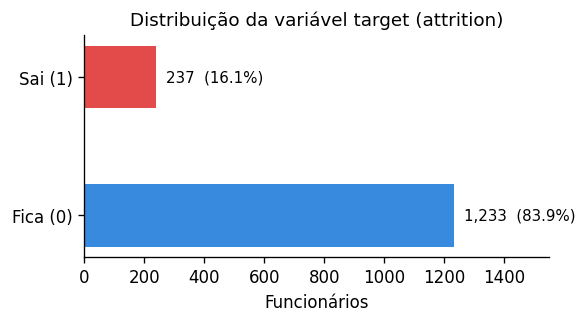

Razão de desbalanceamento: 1 : 5.2
→ Será corrigido com SMOTE no treino e class_weight='balanced' no modelo.


In [5]:
# ── 2.1 Desbalanceamento de classes ─────────────────────────────────────────
total    = len(df)
n_sai    = df["attrition"].sum()
n_fica   = total - n_sai
taxa     = n_sai / total

fig, ax = plt.subplots(figsize=(5, 2.8))
bars = ax.barh(["Fica (0)", "Sai (1)"], [n_fica, n_sai],
               color=["#378ADD", "#E24B4A"], height=0.45)
ax.bar_label(bars, labels=[f"{n_fica:,}  ({1-taxa:.1%})", f"{n_sai:,}  ({taxa:.1%})"],
             padding=6, fontsize=9)
ax.set_xlim(0, 1550)
ax.set_xlabel("Funcionários")
ax.set_title("Distribuição da variável target (attrition)", fontsize=11, fontweight="normal")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_desbalanceamento.png", bbox_inches="tight")
plt.show()

print(f"Razão de desbalanceamento: 1 : {n_fica/n_sai:.1f}")
print("→ Será corrigido com SMOTE no treino e class_weight='balanced' no modelo.")


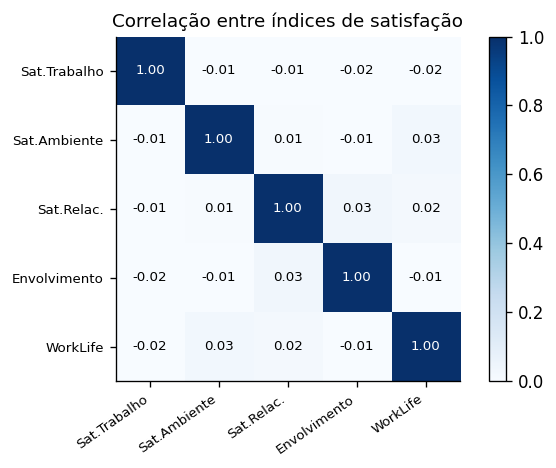

Correlações altas (>0.5) indicam features redundantes — mantemos todas pois
o Random Forest lida bem com colinearidade moderada.


In [6]:
# ── 2.2 Correlação das features de satisfação ────────────────────────────────
SAT_COLS = [
    "satisfacao_trabalho_cod", "satisfacao_ambiente_cod",
    "satisfacao_relacionamento_cod", "envolvimento_trabalho_cod",
    "equilibrio_vida_trabalho_cod",
]

corr = df[SAT_COLS].corr()

fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(SAT_COLS)))
ax.set_yticks(range(len(SAT_COLS)))
labels_short = ["Sat.Trabalho","Sat.Ambiente","Sat.Relac.","Envolvimento","WorkLife"]
ax.set_xticklabels(labels_short, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(labels_short, fontsize=8)
for i in range(len(SAT_COLS)):
    for j in range(len(SAT_COLS)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if corr.iloc[i,j] > 0.6 else "black")
ax.set_title("Correlação entre índices de satisfação", fontsize=11, fontweight="normal")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_corr_satisfacao.png", bbox_inches="tight")
plt.show()

print("Correlações altas (>0.5) indicam features redundantes — mantemos todas pois")
print("o Random Forest lida bem com colinearidade moderada.")


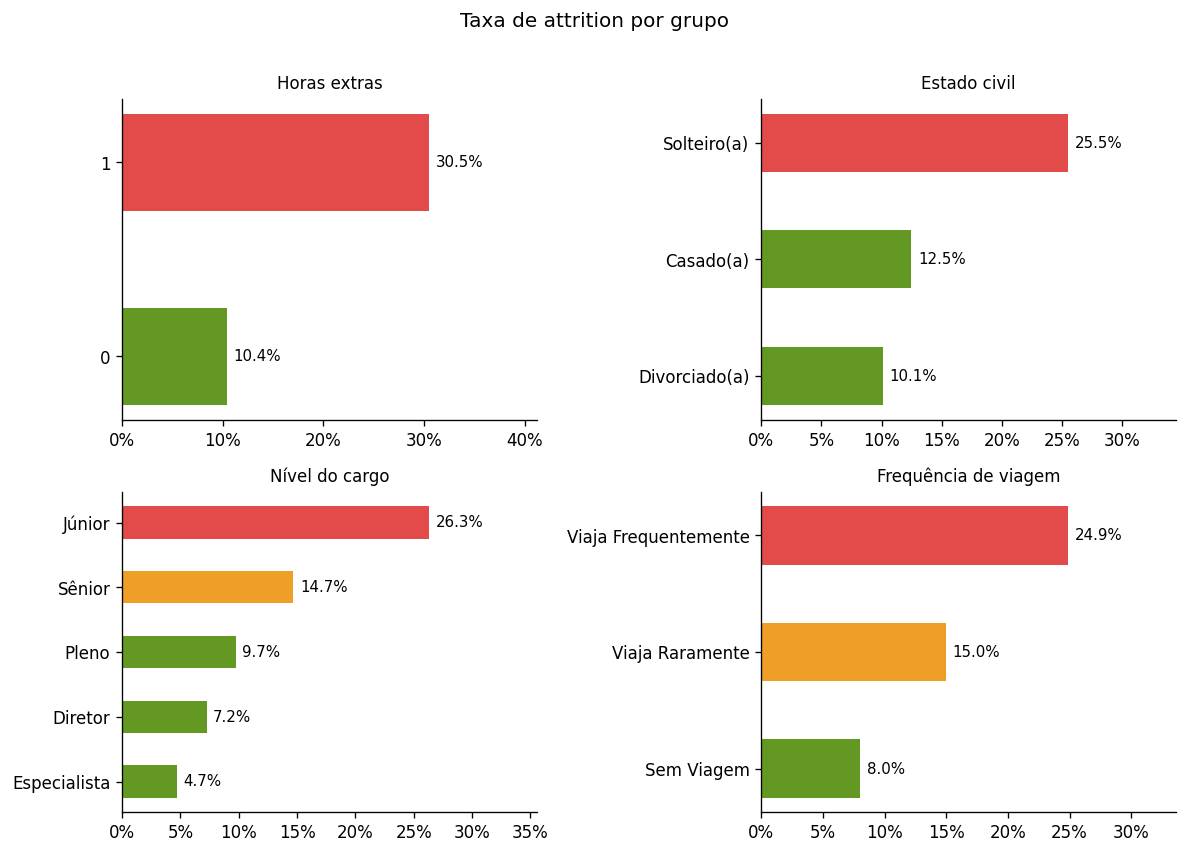

In [7]:
# ── 2.3 Taxa de attrition por grupo — top fatores visuais ───────────────────
grupos = {
    "horas_extras"        : {1: "Com horas extras", 0: "Sem horas extras"},
    "estado_civil"        : None,
    "nivel_cargo"         : None,
    "frequencia_viagem"   : None,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

variaveis = ["horas_extras", "estado_civil", "nivel_cargo", "frequencia_viagem"]
titulos   = ["Horas extras", "Estado civil", "Nível do cargo", "Frequência de viagem"]

for ax, col, titulo in zip(axes, variaveis, titulos):
    taxa_grupo = (
        df.groupby(col)["attrition"]
        .mean()
        .sort_values(ascending=True)
    )
    colors = ["#E24B4A" if v > 0.20 else "#EF9F27" if v > 0.13 else "#639922"
              for v in taxa_grupo.values]
    bars = ax.barh(taxa_grupo.index.astype(str), taxa_grupo.values, color=colors, height=0.5)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in taxa_grupo.values], padding=4, fontsize=9)
    ax.set_xlim(0, taxa_grupo.max() * 1.35)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(titulo, fontsize=10, fontweight="normal")

plt.suptitle("Taxa de attrition por grupo", fontsize=12, fontweight="normal", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_attrition_grupos.png", bbox_inches="tight")
plt.show()


---
## 3. Pré-processamento

Codificação de categóricas e definição do conjunto de features.

In [8]:
# ── Definição das features ───────────────────────────────────────────────────
CAT_COLS = [
    "genero", "estado_civil", "departamento", "cargo", "area_formacao",
    "frequencia_viagem", "nivel_cargo", "nivel_educacao",
    "faixa_etaria", "faixa_renda", "nivel_risco",
]
NUM_COLS = [
    "idade", "renda_mensal", "taxa_diaria", "taxa_horaria",
    "perc_aumento_salarial", "nivel_stock_option",
    "anos_empresa", "anos_cargo_atual", "anos_desde_ultima_promocao",
    "anos_mesmo_gestor", "anos_experiencia_total", "qtd_empresas_anteriores",
    "distancia_casa_km", "treinamentos_ultimo_ano", "nivel_cargo_cod",
    "perc_carreira_empresa", "media_anos_por_empresa_anterior",
    "indice_estagnacao_cargo",
    "satisfacao_trabalho_cod", "satisfacao_ambiente_cod",
    "satisfacao_relacionamento_cod", "envolvimento_trabalho_cod",
    "equilibrio_vida_trabalho_cod", "score_bemestar",
]
BIN_COLS = [
    "horas_extras",
    "flag_horas_extras", "flag_sem_promocao_3a", "flag_distancia_alta",
    "flag_satisfacao_baixa", "flag_renda_abaixo_mediana",
]

FEATURES = NUM_COLS + CAT_COLS + BIN_COLS
TARGET   = "attrition"

print(f"Total de features: {len(FEATURES)}")
print(f"  Numéricas  : {len(NUM_COLS)}")
print(f"  Categóricas: {len(CAT_COLS)}")
print(f"  Binárias   : {len(BIN_COLS)}")


Total de features: 41
  Numéricas  : 24
  Categóricas: 11
  Binárias   : 6


In [9]:
# ── Encoding ─────────────────────────────────────────────────────────────────
df_enc = df.copy()

# Guarda os encoders para poder inverter labels se necessário
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    encoders[col] = le

for col in BIN_COLS:
    df_enc[col] = df_enc[col].astype(int)

X = df_enc[FEATURES].fillna(0)
y = df_enc[TARGET].astype(int)

print("Shape X:", X.shape)
print("Nulos em X:", X.isnull().sum().sum())
print("Distribuição y:", y.value_counts().to_dict())


Shape X: (1470, 41)
Nulos em X: 0
Distribuição y: {0: 1233, 1: 237}


In [10]:
# ── Train / test split estratificado ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Treino : {X_train.shape[0]:,} amostras  "
      f"(positivos: {y_train.sum()} = {y_train.mean():.1%})")
print(f"Teste  : {X_test.shape[0]:,} amostras  "
      f"(positivos: {y_test.sum()} = {y_test.mean():.1%})")


Treino : 1,176 amostras  (positivos: 190 = 16.2%)
Teste  : 294 amostras  (positivos: 47 = 16.0%)


---
## 4. Treino — Random Forest com SMOTE

SMOTE é aplicado **apenas no conjunto de treino** para evitar data leakage.  
`class_weight='balanced'` reforça a correção do desbalanceamento.

In [11]:
# ── Aplicar SMOTE somente no treino ─────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE : {y_train.value_counts().to_dict()}")
print(f"Após  o SMOTE  : {pd.Series(y_train_res).value_counts().to_dict()}")


Antes do SMOTE : {0: 986, 1: 190}
Após  o SMOTE  : {0: 986, 1: 986}


In [12]:
# ── Treino do modelo ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators   = 300,
    max_depth      = None,
    min_samples_leaf = 4,
    class_weight   = "balanced",
    random_state   = 42,
    n_jobs         = -1,
)

rf.fit(X_train_res, y_train_res)
print("Modelo treinado.")
print(f"  Árvores : {rf.n_estimators}")
print(f"  Features: {rf.n_features_in_}")


Modelo treinado.
  Árvores : 300
  Features: 41


---
## 5. Avaliação do modelo

Métricas corretas para dados desbalanceados: **ROC-AUC** e **Precision-Recall**.  
Acurácia simples é enganosa aqui — um modelo que sempre diz "fica" teria 84% de acurácia.

In [13]:
# ── Cross-validation 5-fold ──────────────────────────────────────────────────
pipe_cv = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf",    RandomForestClassifier(
        n_estimators=300, min_samples_leaf=4,
        class_weight="balanced", random_state=42, n_jobs=-1
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_cv, X, y, cv=cv, scoring="roc_auc")

print("Cross-validation ROC-AUC (5 folds):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Média : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Cross-validation ROC-AUC (5 folds):
  Fold 1: 0.7752
  Fold 2: 0.7459
  Fold 3: 0.7896
  Fold 4: 0.7903
  Fold 5: 0.7595
  Média : 0.7721 ± 0.0173


In [14]:
# ── Avaliação no conjunto de teste ───────────────────────────────────────────
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.40).astype(int)   # threshold ajustado para maior recall

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC no teste: {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Fica (0)", "Sai (1)"]))


ROC-AUC no teste: 0.7405

              precision    recall  f1-score   support

    Fica (0)       0.90      0.81      0.85       247
     Sai (1)       0.33      0.51      0.40        47

    accuracy                           0.76       294
   macro avg       0.61      0.66      0.63       294
weighted avg       0.81      0.76      0.78       294



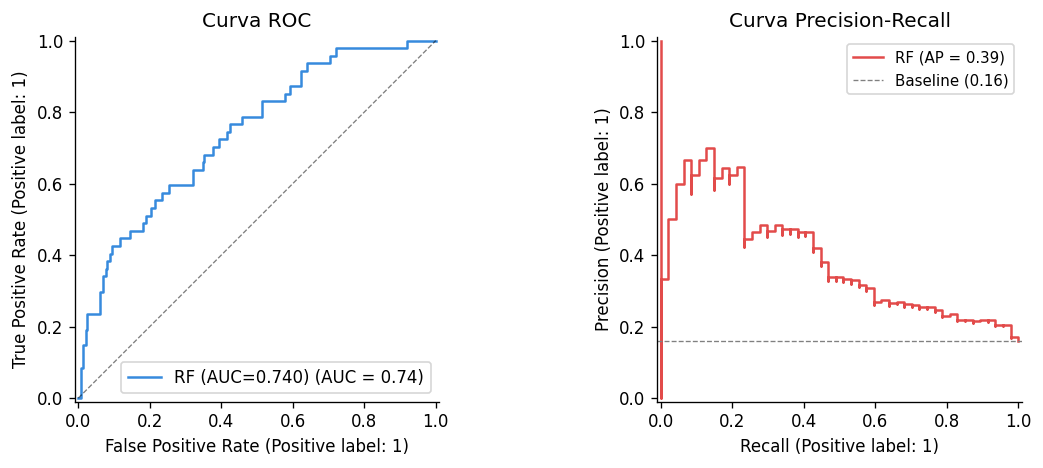

In [15]:
# ── Curvas ROC e Precision-Recall ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0],
                                  color="#378ADD", name=f"RF (AUC={auc:.3f})")
axes[0].plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.5)
axes[0].set_title("Curva ROC", fontweight="normal")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                         color="#E24B4A", name="RF")
baseline = y_test.mean()
axes[1].axhline(baseline, color="gray", linestyle="--", linewidth=0.8,
                label=f"Baseline ({baseline:.2f})")
axes[1].legend(fontsize=9)
axes[1].set_title("Curva Precision-Recall", fontweight="normal")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_curvas_avaliacao.png", bbox_inches="tight")
plt.show()


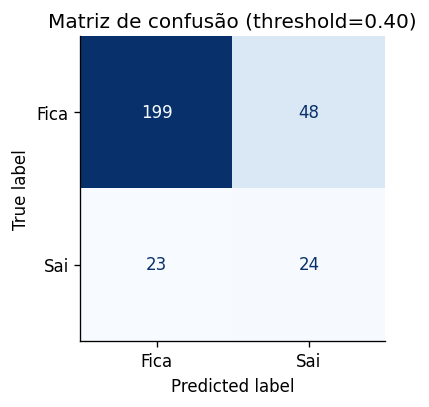

Verdadeiros positivos (capturados que saíram) : 24
Falsos negativos (quem saiu mas não detectou) : 23
Falsos positivos (alarme falso)               : 48
Recall dos que saem                           : 51.1%


In [16]:
# ── Matriz de confusão ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fica", "Sai"])

fig, ax = plt.subplots(figsize=(4, 3.5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusão (threshold=0.40)", fontweight="normal")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_matriz_confusao.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros positivos (capturados que saíram) : {tp}")
print(f"Falsos negativos (quem saiu mas não detectou) : {fn}")
print(f"Falsos positivos (alarme falso)               : {fp}")
print(f"Recall dos que saem                           : {tp/(tp+fn):.1%}")


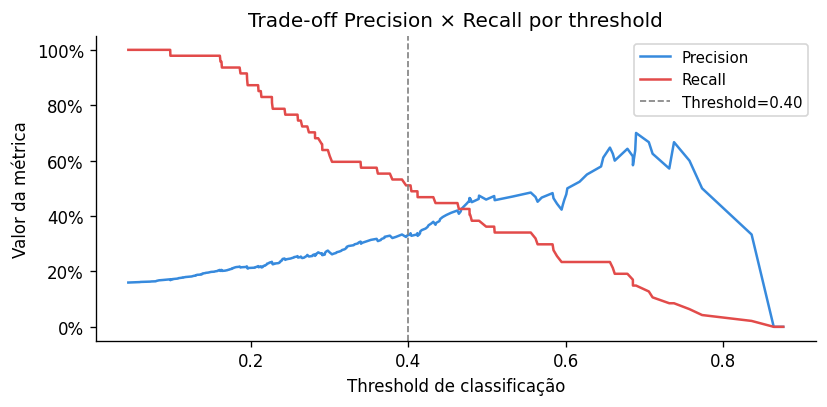

Dica: threshold mais baixo → mais recall (captura mais quem sai)
      threshold mais alto  → mais precision (menos alarmes falsos)
Para RH, priorize recall — é pior perder um funcionário que mandar alerta extra.


In [17]:
# ── Análise de threshold ─────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, precisions[:-1], color="#378ADD", label="Precision", linewidth=1.5)
ax.plot(thresholds, recalls[:-1],    color="#E24B4A", label="Recall",    linewidth=1.5)
ax.axvline(0.40, color="gray", linestyle="--", linewidth=1, label="Threshold=0.40")
ax.set_xlabel("Threshold de classificação")
ax.set_ylabel("Valor da métrica")
ax.set_title("Trade-off Precision × Recall por threshold", fontweight="normal")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_threshold.png", bbox_inches="tight")
plt.show()

print("Dica: threshold mais baixo → mais recall (captura mais quem sai)")
print("      threshold mais alto  → mais precision (menos alarmes falsos)")
print("Para RH, priorize recall — é pior perder um funcionário que mandar alerta extra.")


---
## 6. Feature Importance global

Quais variáveis o modelo considera mais relevantes para prever attrition.

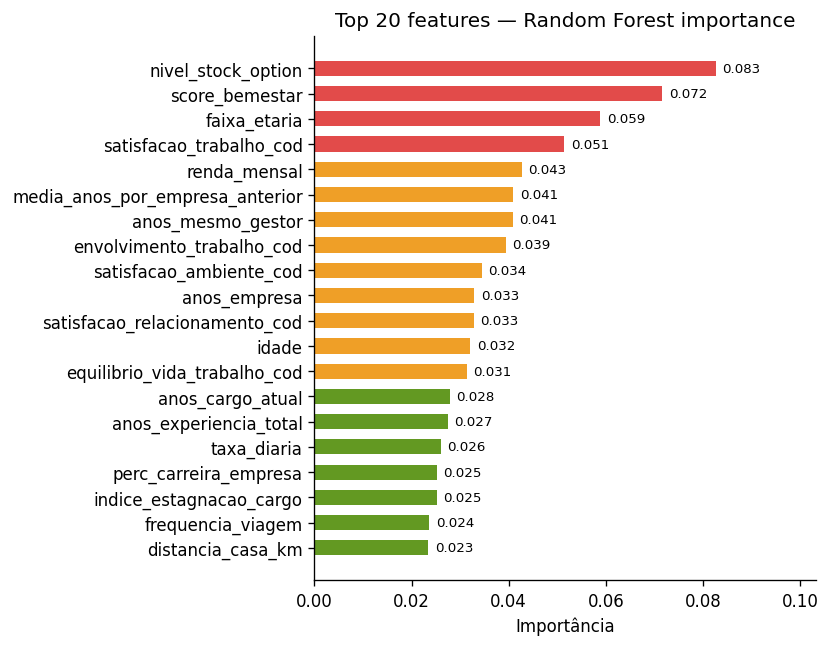

Top 10 features:
nivel_stock_option                 0.082627
score_bemestar                     0.071598
faixa_etaria                       0.058885
satisfacao_trabalho_cod            0.051430
renda_mensal                       0.042723
media_anos_por_empresa_anterior    0.040973
anos_mesmo_gestor                  0.040789
envolvimento_trabalho_cod          0.039414
satisfacao_ambiente_cod            0.034413
anos_empresa                       0.032918


In [18]:
# ── Feature importance do Random Forest ─────────────────────────────────────
fi = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["#E24B4A" if v > 0.05 else "#EF9F27" if v > 0.03 else "#639922"
          for v in fi.values]
bars = ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], height=0.6)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in fi.values[::-1]],
             padding=4, fontsize=8)
ax.set_xlim(0, fi.max() * 1.25)
ax.set_xlabel("Importância")
ax.set_title("Top 20 features — Random Forest importance", fontweight="normal")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_feature_importance.png", bbox_inches="tight")
plt.show()

print("Top 10 features:")
print(fi.head(10).to_string())


---
## 7. SHAP — Interpretabilidade individual

SHAP (SHapley Additive exPlanations) explica **por que** cada funcionário tem a probabilidade que tem.  
- Valor SHAP positivo → aumenta a probabilidade de saída  
- Valor SHAP negativo → reduz a probabilidade de saída

In [19]:
# ── Calcular SHAP values para todo o dataset ─────────────────────────────────
print("Calculando SHAP values (pode levar ~30 segundos)...")
explainer  = shap.TreeExplainer(rf)
shap_raw   = explainer.shap_values(X)

# shap_raw pode ser lista [class0, class1] ou array 3D dependendo da versão
if isinstance(shap_raw, list):
    shap_matrix = shap_raw[1]           # valores para classe "Sai"
elif shap_raw.ndim == 3:
    shap_matrix = shap_raw[:, :, 1]     # (n_samples, n_features, n_classes)
else:
    shap_matrix = shap_raw

print(f"Shape da matriz SHAP: {shap_matrix.shape}")
print("Concluído.")


Calculando SHAP values (pode levar ~30 segundos)...
Shape da matriz SHAP: (1470, 41)
Concluído.


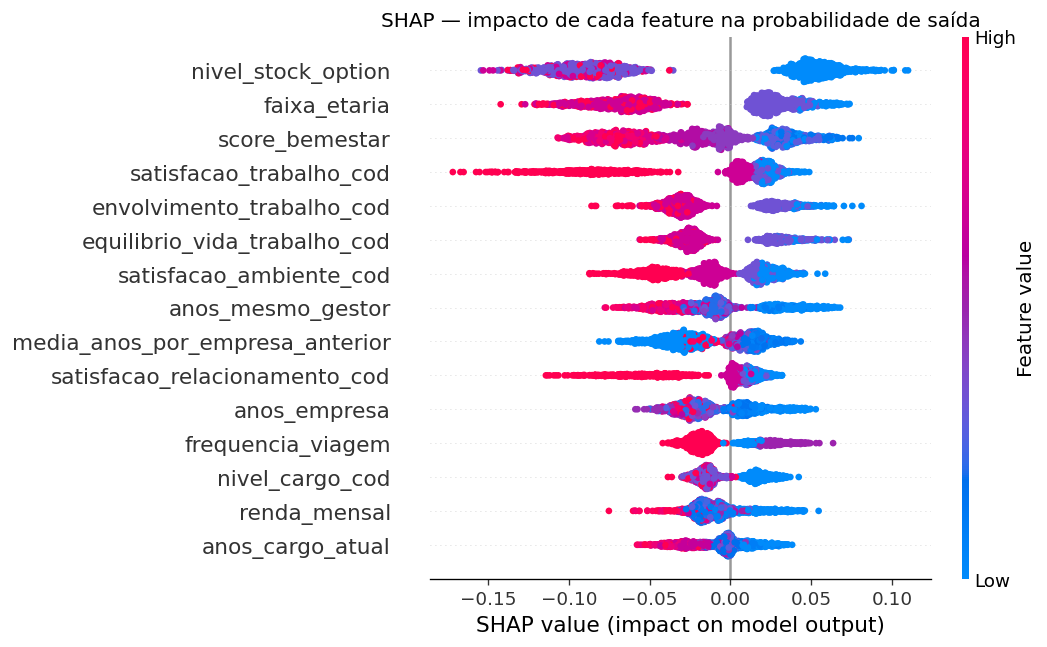

Vermelho = valor alto da feature  |  Azul = valor baixo
Posição no eixo X = direção do impacto na probabilidade


In [20]:
# ── Beeswarm plot — visão global ─────────────────────────────────────────────
shap.summary_plot(
    shap_matrix,
    X,
    feature_names=FEATURES,
    max_display=15,
    show=False,
    plot_size=(9, 5.5),
)
plt.title("SHAP — impacto de cada feature na probabilidade de saída", fontweight="normal")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_shap_beeswarm.png", bbox_inches="tight")
plt.show()
print("Vermelho = valor alto da feature  |  Azul = valor baixo")
print("Posição no eixo X = direção do impacto na probabilidade")


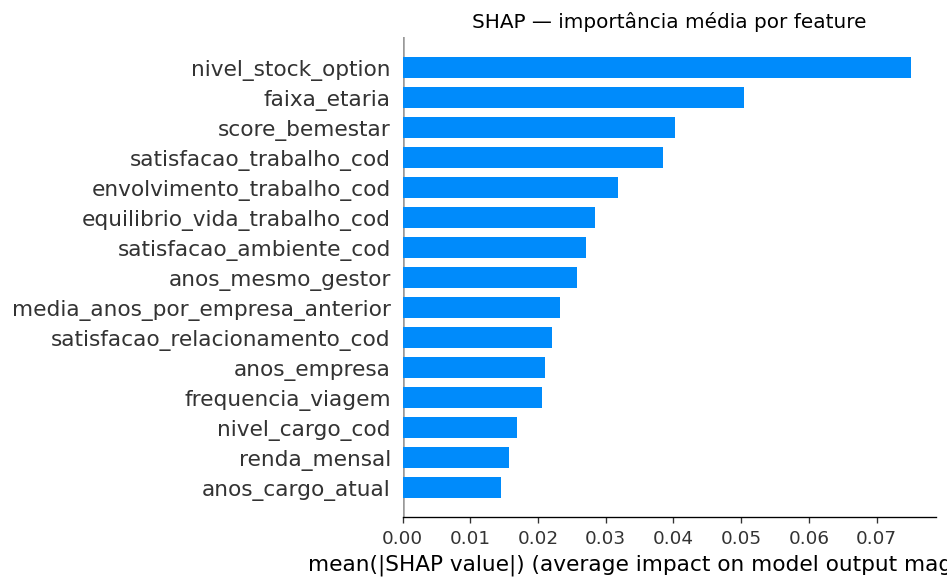

In [21]:
# ── Bar plot SHAP médio ───────────────────────────────────────────────────────
shap.summary_plot(
    shap_matrix,
    X,
    feature_names=FEATURES,
    plot_type="bar",
    max_display=15,
    show=False,
    plot_size=(8, 5),
)
plt.title("SHAP — importância média por feature", fontweight="normal")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_shap_bar.png", bbox_inches="tight")
plt.show()


In [22]:
# ── Explicação individual — exemplo de funcionário de alto risco ─────────────
# Pega o funcionário com maior probabilidade de attrition
prob_todos = rf.predict_proba(X)[:, 1]
idx_alto   = prob_todos.argmax()

funcionario_id   = df.iloc[idx_alto]["id_funcionario"]
prob_attrition   = prob_todos[idx_alto]
cargo_func       = df.iloc[idx_alto]["cargo"]
dept_func        = df.iloc[idx_alto]["departamento"]

print(f"Funcionário de exemplo: ID {funcionario_id}")
print(f"  Cargo         : {cargo_func}")
print(f"  Departamento  : {dept_func}")
print(f"  Prob. attrition: {prob_attrition:.1%}")
print()

# Top fatores individuais (SHAP)
shap_ind = pd.Series(shap_matrix[idx_alto], index=FEATURES).sort_values(key=abs, ascending=False)
top_pos  = shap_ind[shap_ind > 0].head(5)
top_neg  = shap_ind[shap_ind < 0].head(3)

print("Fatores que AUMENTAM o risco de saída:")
for feat, val in top_pos.items():
    print(f"  +{val:.4f}  {feat} = {X.iloc[idx_alto][feat]}")

print()
print("Fatores que REDUZEM o risco de saída:")
for feat, val in top_neg.items():
    print(f"  {val:.4f}  {feat} = {X.iloc[idx_alto][feat]}")


Funcionário de exemplo: ID 1944
  Cargo         : Human Resources
  Departamento  : Human Resources
  Prob. attrition: 96.2%

Fatores que AUMENTAM o risco de saída:
  +0.0660  nivel_stock_option = 0.0
  +0.0504  anos_mesmo_gestor = 0.0
  +0.0498  faixa_etaria = 1.0
  +0.0392  anos_empresa = 1.0
  +0.0383  score_bemestar = 1.8

Fatores que REDUZEM o risco de saída:
  -0.0237  media_anos_por_empresa_anterior = 0.0
  -0.0172  perc_carreira_empresa = 1.0
  -0.0136  equilibrio_vida_trabalho_cod = 3.0


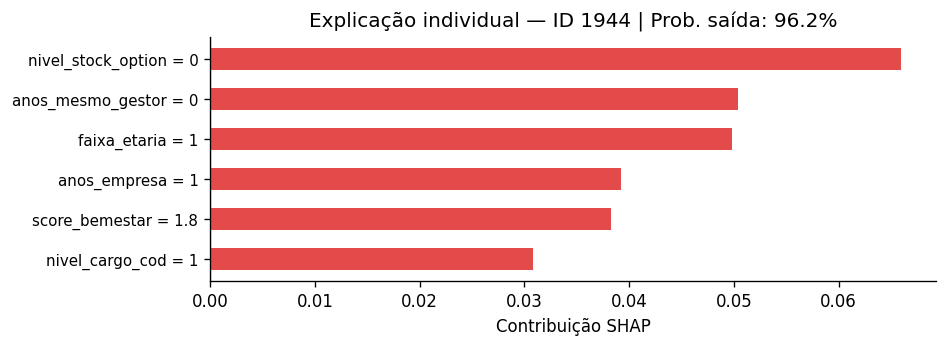

In [23]:
# ── Force plot textual (top 6 fatores por magnitude) ────────────────────────
shap_ind_abs = shap_matrix[idx_alto].copy()
top6_idx     = np.argsort(np.abs(shap_ind_abs))[::-1][:6]
top6_feats   = [FEATURES[i] for i in top6_idx]
top6_vals    = shap_ind_abs[top6_idx]
top6_data    = X.iloc[idx_alto].values[top6_idx]

fig, ax = plt.subplots(figsize=(8, 3))
colors  = ["#E24B4A" if v > 0 else "#378ADD" for v in top6_vals]
bars    = ax.barh(range(6), top6_vals[::-1], color=colors[::-1], height=0.55)

labels = [f"{top6_feats[5-i]} = {top6_data[5-i]:.2g}" for i in range(6)]
ax.set_yticks(range(6))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Contribuição SHAP")
ax.set_title(
    f"Explicação individual — ID {funcionario_id} | Prob. saída: {prob_attrition:.1%}",
    fontweight="normal"
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_shap_individual.png", bbox_inches="tight")
plt.show()


---
## 8. Exportação para Power BI

Adiciona ao CSV principal:
- `prob_attrition` — probabilidade individual (0–1)  
- `nivel_risco_ml` — segmentação em 4 bandas calibradas pelos dados  
- `shap_top1_feat` até `shap_top3_feat` — nome das 3 features mais impactantes  
- `shap_top1_val` até `shap_top3_val` — valor SHAP correspondente  
- `acao_recomendada` — sugestão automática baseada no fator principal

In [24]:
# ── Probabilidades para todo o dataset ───────────────────────────────────────
prob_todos = rf.predict_proba(X)[:, 1]

df_out = df.copy()
df_out["prob_attrition"] = prob_todos.round(4)

# Bandas de risco baseadas em percentis reais do modelo
p25 = np.percentile(prob_todos, 25)
p50 = np.percentile(prob_todos, 50)
p75 = np.percentile(prob_todos, 75)

df_out["nivel_risco_ml"] = pd.cut(
    prob_todos,
    bins    = [0, p25, p50, p75, 1.001],
    labels  = ["Baixo", "Médio", "Alto", "Crítico"],
    include_lowest=True,
)

print("Distribuição nivel_risco_ml:")
print(df_out["nivel_risco_ml"].value_counts().sort_index().to_string())
print()
print(f"Cortes: Baixo<{p25:.2f} | Médio<{p50:.2f} | Alto<{p75:.2f} | Crítico≥{p75:.2f}")


Distribuição nivel_risco_ml:
nivel_risco_ml
Baixo      368
Médio      367
Alto       367
Crítico    368

Cortes: Baixo<0.11 | Médio<0.19 | Alto<0.33 | Crítico≥0.33


In [25]:
# ── Top 3 razões SHAP por funcionário ────────────────────────────────────────
print("Calculando top 3 razões SHAP por funcionário...")

shap_feat_names = np.array(FEATURES)
top1_feats, top2_feats, top3_feats = [], [], []
top1_vals,  top2_vals,  top3_vals  = [], [], []

for i in range(len(df_out)):
    row_shap = shap_matrix[i]
    # Somente features que AUMENTAM o risco (SHAP positivo)
    pos_mask = row_shap > 0
    if pos_mask.sum() >= 3:
        top_idx = np.argsort(row_shap * pos_mask)[::-1][:3]
    else:
        top_idx = np.argsort(np.abs(row_shap))[::-1][:3]

    top1_feats.append(shap_feat_names[top_idx[0]])
    top2_feats.append(shap_feat_names[top_idx[1]])
    top3_feats.append(shap_feat_names[top_idx[2]])
    top1_vals.append(round(float(row_shap[top_idx[0]]), 4))
    top2_vals.append(round(float(row_shap[top_idx[1]]), 4))
    top3_vals.append(round(float(row_shap[top_idx[2]]), 4))

df_out["shap_top1_feat"] = top1_feats
df_out["shap_top2_feat"] = top2_feats
df_out["shap_top3_feat"] = top3_feats
df_out["shap_top1_val"]  = top1_vals
df_out["shap_top2_val"]  = top2_vals
df_out["shap_top3_val"]  = top3_vals

print("Concluído.")
df_out[["id_funcionario","prob_attrition","nivel_risco_ml",
        "shap_top1_feat","shap_top1_val",
        "shap_top2_feat","shap_top2_val"]].head(5)


Calculando top 3 razões SHAP por funcionário...
Concluído.


,id_funcionario,prob_attrition,nivel_risco_ml,shap_top1_feat,shap_top1_val,shap_top2_feat,shap_top2_val
0,1,0.5757,Crítico,nivel_stock_option,0.0782,score_bemestar,0.0525
1,2,0.0853,Baixo,envolvimento_trabalho_cod,0.0192,frequencia_viagem,0.0168
2,4,0.4030,Crítico,nivel_stock_option,0.0483,anos_mesmo_gestor,0.0384
3,5,0.4152,Crítico,nivel_stock_option,0.0662,anos_mesmo_gestor,0.0415
4,7,0.2927,Alto,faixa_etaria,0.0355,satisfacao_ambiente_cod,0.0330


In [26]:
# ── Ação recomendada baseada no fator principal ───────────────────────────────
MAPA_ACAO = {
    "horas_extras"                 : "Reduzir horas extras / revisar carga",
    "flag_horas_extras"            : "Reduzir horas extras / revisar carga",
    "renda_mensal"                 : "Revisar posicionamento salarial",
    "flag_renda_abaixo_mediana"    : "Revisar posicionamento salarial",
    "anos_desde_ultima_promocao"   : "Agendar conversa de carreira / promoção",
    "flag_sem_promocao_3a"         : "Agendar conversa de carreira / promoção",
    "satisfacao_trabalho_cod"      : "Conversa 1:1 sobre satisfação no trabalho",
    "satisfacao_ambiente_cod"      : "Avaliar condições e ambiente de trabalho",
    "satisfacao_relacionamento_cod": "Avaliar dinâmica de equipe / gestor",
    "envolvimento_trabalho_cod"    : "Aumentar desafios / responsabilidades",
    "equilibrio_vida_trabalho_cod" : "Revisar jornada e flexibilidade",
    "score_bemestar"               : "Programa de bem-estar e saúde mental",
    "distancia_casa_km"            : "Avaliar home office / subsídio transporte",
    "flag_distancia_alta"          : "Avaliar home office / subsídio transporte",
    "nivel_stock_option"           : "Revisar benefícios e stock options",
    "qtd_empresas_anteriores"      : "Plano de desenvolvimento e retenção",
}

df_out["acao_recomendada"] = df_out["shap_top1_feat"].map(MAPA_ACAO).fillna(
    "Conversa de retenção personalizada"
)

print("Distribuição das ações recomendadas:")
print(df_out["acao_recomendada"].value_counts().to_string())


Distribuição das ações recomendadas:
acao_recomendada
Revisar benefícios e stock options           567
Conversa de retenção personalizada           379
Aumentar desafios / responsabilidades        128
Revisar jornada e flexibilidade              126
Programa de bem-estar e saúde mental         111
Avaliar condições e ambiente de trabalho      69
Conversa 1:1 sobre satisfação no trabalho     59
Revisar posicionamento salarial               13
Avaliar dinâmica de equipe / gestor            8
Agendar conversa de carreira / promoção        4
Reduzir horas extras / revisar carga           3
Avaliar home office / subsídio transporte      3


In [27]:
# ── Exportação final ──────────────────────────────────────────────────────────
COLUNAS_EXPORTAR = [c for c in df_out.columns
                    if c not in ["faixa_etaria","faixa_renda","nivel_risco"]]

# Remove colunas de satisfação que já estão em dim_satisfacao
SAT_REMOVER = [c for c in df_out.columns
               if c.endswith("_cod") and c in
               ["satisfacao_trabalho_cod","satisfacao_ambiente_cod",
                "satisfacao_relacionamento_cod","envolvimento_trabalho_cod",
                "equilibrio_vida_trabalho_cod"]]

COLUNAS_EXPORTAR = [c for c in COLUNAS_EXPORTAR if c not in SAT_REMOVER]

df_final = df_out[COLUNAS_EXPORTAR].copy()

# Categoricals → string para compatibilidade
for col in df_final.select_dtypes("category").columns:
    df_final[col] = df_final[col].astype(str)

df_final.to_csv(f"{OUTPUT_DIR}/fato_funcionarios_ml.csv", index=False, encoding="utf-8-sig")

print(f"fato_funcionarios_ml.csv  →  {df_final.shape[0]:,} linhas × {df_final.shape[1]} colunas")
print()
print("Novas colunas adicionadas vs fato_funcionarios.csv:")
novas = set(df_final.columns) - set(fato.columns)
for c in sorted(novas):
    print(f"  + {c}")


fato_funcionarios_ml.csv  →  1,470 linhas × 46 colunas

Novas colunas adicionadas vs fato_funcionarios.csv:
  + acao_recomendada
  + nivel_risco_ml
  + prob_attrition
  + score_bemestar
  + shap_top1_feat
  + shap_top1_val
  + shap_top2_feat
  + shap_top2_val
  + shap_top3_feat
  + shap_top3_val


In [28]:
# ── Manifesto de saída ────────────────────────────────────────────────────────
from datetime import datetime

criticos = (df_out["nivel_risco_ml"] == "Crítico").sum()
altos    = (df_out["nivel_risco_ml"] == "Alto").sum()

print("=" * 60)
print("PIPELINE ML CONCLUÍDO")
print("=" * 60)
print(f"ROC-AUC cross-validation : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Funcionários Críticos    : {criticos} ({criticos/len(df_out):.1%})")
print(f"Funcionários Alto risco  : {altos}    ({altos/len(df_out):.1%})")
print(f"Gerado em                : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Arquivo                  : {OUTPUT_DIR}/fato_funcionarios_ml.csv")
print("=" * 60)


PIPELINE ML CONCLUÍDO
ROC-AUC cross-validation : 0.7721 ± 0.0173
Funcionários Críticos    : 368 (25.0%)
Funcionários Alto risco  : 367    (25.0%)
Gerado em                : 2026-06-12 15:51:05
Arquivo                  : output_pbi/fato_funcionarios_ml.csv


---
## 9. Guia de uso no Power BI

### Substituir a tabela fato

1. No Power BI, substitua `fato_funcionarios.csv` por **`fato_funcionarios_ml.csv`**  
2. Os relacionamentos com `dim_cargos` e `dim_satisfacao` permanecem iguais  

### Novas colunas disponíveis

| Coluna | Tipo | Uso |
|--------|------|-----|
| `prob_attrition` | Decimal (0–1) | KPI gauge, ranking, scatter |
| `nivel_risco_ml` | Texto | Slicer, segmentação, cor condicional |
| `shap_top1_feat` | Texto | Tooltip "principal motivo" |
| `shap_top2_feat` | Texto | Tooltip "2º motivo" |
| `shap_top3_feat` | Texto | Tooltip "3º motivo" |
| `shap_top1_val` | Decimal | Magnitude do fator 1 |
| `acao_recomendada` | Texto | Tabela de ações para o RH |

### Medidas DAX com o novo modelo

```dax
-- Probabilidade média de attrition
Prob Média Attrition =
    AVERAGE(fato_funcionarios_ml[prob_attrition])

-- Funcionários Críticos
Funcionários Críticos =
    COUNTROWS(
        FILTER(fato_funcionarios_ml, [nivel_risco_ml] = "Crítico")
    )

-- Custo em risco (soma de reposição do grupo Crítico)
Custo em Risco =
    SUMX(
        FILTER(fato_funcionarios_ml, [nivel_risco_ml] IN {"Crítico","Alto"}),
        [custo_reposicao_est]
    )

-- Tabela de ações mais frequentes
Top Acao =
    FIRSTNONBLANK(
        TOPN(1,
            SUMMARIZE(fato_funcionarios_ml, [acao_recomendada],
                      "Qtd", COUNTROWS(fato_funcionarios_ml)),
            [Qtd], DESC
        ),
        1
    )
```

### Painel de risco operacional — visuais sugeridos

- **Tabela detalhada** filtrada por `nivel_risco_ml = Crítico`:  
  colunas `cargo`, `departamento`, `prob_attrition`, `shap_top1_feat`, `acao_recomendada`  
  com formatação condicional de cor em `prob_attrition`
- **Gauge** com `Prob Média Attrition` vs meta (<15%)
- **Treemap** de `acao_recomendada` por frequência — mostra onde concentrar esforços
- **Scatter** `prob_attrition` × `renda_mensal` colorido por `nivel_risco_ml`
- **Slicer** por `nivel_risco_ml`, `departamento`, `cargo`
